In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Setup and Data Loading ---

# Load the dataset
# Ensure '/content/netflix1.csv' is in the same directory as the script
try:
    data = pd.read_csv('/content/netflix1.csv')
    print("Data Loaded Successfully. Initial shape:", data.shape)
except FileNotFoundError:
    print("Error: /content/netflix1.csv not found. Please ensure the file is in the correct path.")
    exit()

Data Loaded Successfully. Initial shape: (8790, 10)


In [13]:
# --- Step 2: Data Cleaning and Preprocessing ---

# 1. Treat the Nulls and Populate missing rows
# Fill missing 'director' and 'country' with 'Not Given'
data['director'] = data['director'].fillna('Not Given')
data['country'] = data['country'].fillna('Not Given')

# Drop rows where 'date_added' is null, as this is important for time series analysis (if performed)
data.dropna(subset=['date_added'], inplace=True)

# 2. Treat the duplicates
initial_rows = data.shape[0]
data.drop_duplicates(inplace=True)
print(f"Data Cleaning Complete. Dropped {initial_rows - data.shape[0]} duplicate rows.")

Data Cleaning Complete. Dropped 0 duplicate rows.


In [14]:
# --- Step 3: Data Preparation for Analysis ---

# Create segregated DataFrames for movies and TV shows
df_movies = data[data['type'] == 'Movie'].copy()
df_tvshows = data[data['type'] == 'TV Show'].copy()

# Function to calculate popular genres by splitting the 'listed_in' column
def get_popular_genres(dataframe):
    # Split the comma-separated genres, stack them into a series, and count the occurrences
    popular_genres = dataframe['listed_in']\
        .str.split(', ', expand=True)\
        .stack()\
        .value_counts()
    return popular_genres

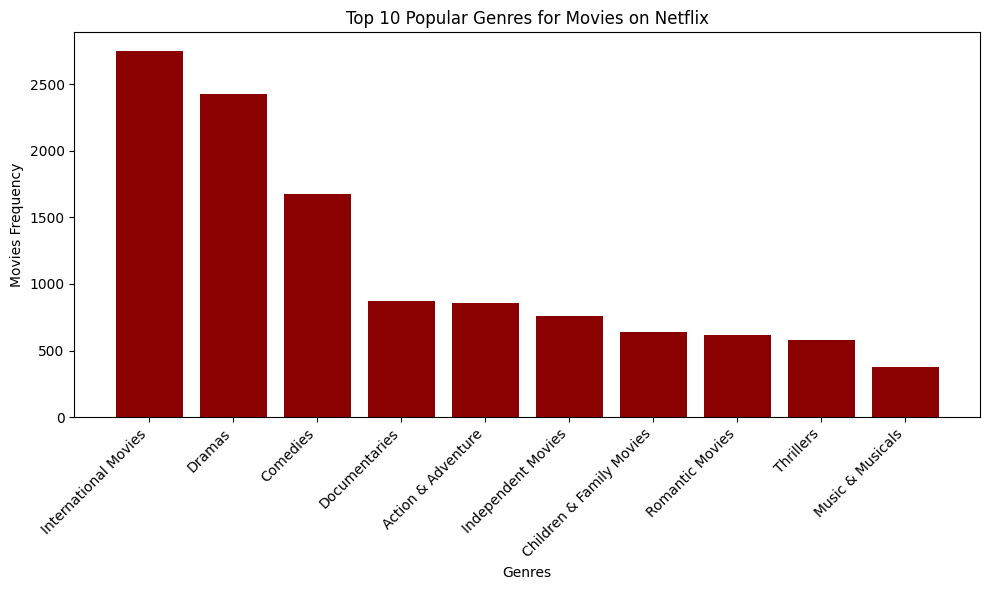


Top 10 Movie Genres Visualization Generated.


In [15]:
# --- Step 4: Analysis and Visualization - Top 10 Movie Genres ---

popular_movie_genre = get_popular_genres(df_movies)[:10]

# Visualization
plt.figure(figsize=(10, 6))
plt.bar(popular_movie_genre.index, popular_movie_genre.values, color='darkred')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Genres")
plt.ylabel("Movies Frequency")
plt.title("Top 10 Popular Genres for Movies on Netflix")
plt.tight_layout()
plt.show()
print("\nTop 10 Movie Genres Visualization Generated.")

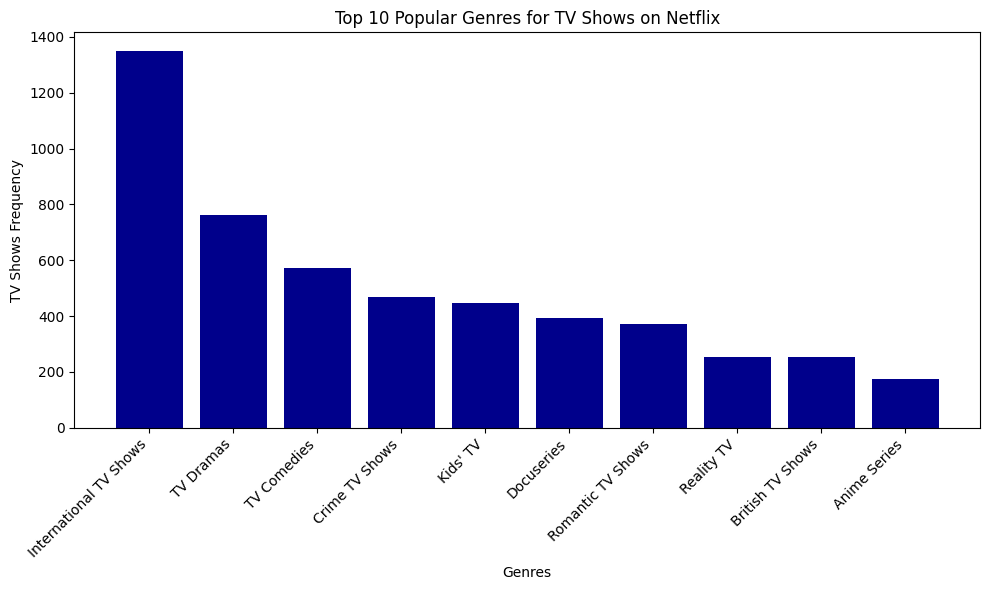


Top 10 TV Show Genres Visualization Generated.


In [16]:
# --- Step 5: Analysis and Visualization - Top 10 TV Show Genres ---

popular_series_genre = get_popular_genres(df_tvshows)[:10]

# Visualization
plt.figure(figsize=(10, 6))
plt.bar(popular_series_genre.index, popular_series_genre.values, color='darkblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Genres")
plt.ylabel("TV Shows Frequency")
plt.title("Top 10 Popular Genres for TV Shows on Netflix")
plt.tight_layout()
plt.show()
print("\nTop 10 TV Show Genres Visualization Generated.")


In [17]:
# --- Step 6: Analysis and Visualization - Top 15 Directors ---

# Count content by director, reset index to make director a column, and rename the count column
# [1:16] is used to skip the first entry, which is the 'Not Given' placeholder, and take the next 15.
directors = data['director'].value_counts()\
    .reset_index(name='count')\
    .rename(columns={'index': 'director'})\
    .sort_values(by='count', ascending=False)[1:16]

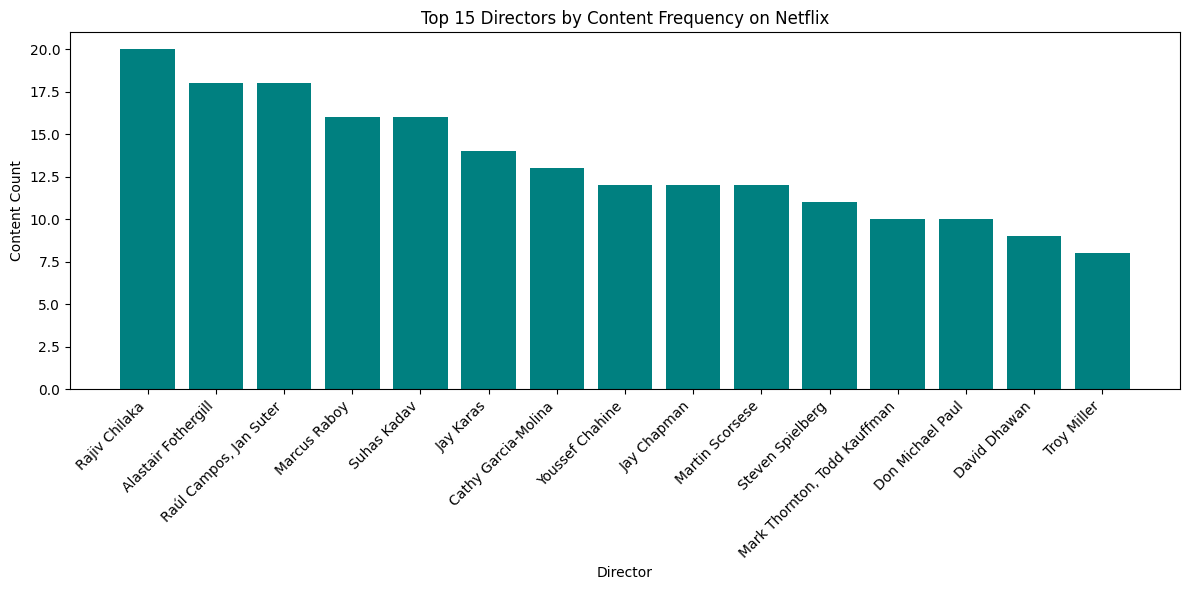


Top 15 Directors Visualization Generated.


In [18]:
# Visualization
plt.figure(figsize=(12, 6))
plt.bar(directors['director'], directors['count'], color='teal')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Director")
plt.ylabel("Content Count")
plt.title("Top 15 Directors by Content Frequency on Netflix")
plt.tight_layout()
plt.show()
print("\nTop 15 Directors Visualization Generated.")